In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드  
> vworld의 중개사 + 중개업자 + 피터팬 크롤링 크롤링 중개사 매칭한 데이터

In [2]:
# 데이터 로드
clean_path = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv"
df = pd.read_csv(clean_path)

print("="*50)
print("데이터 기본 정보")
print("="*50)
print(f"\n데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n기본 통계:\n{df.describe()}")
print(f"\n결측치 정보:\n{df.isnull().sum()}")
df.head()

데이터 기본 정보

데이터 크기: 356행 x 23열

컬럼 목록:
['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단']

데이터 타입:
등록번호          object
중개사명          object
대표자           object
전화번호          object
주소            object
거래완료           int64
등록매물           int64
개설시작일         object
개설종료일         object
등록일           object
상태구분코드       float64
상태구분명         object
지역코드         float64
지역명           object
도로명주소코드       object
최종수정일         object
총_직원수          int64
공인중개사수         int64
중개보조원수         int64
대표수            int64
일반직원수          int64
직원목록_JSON     object
직원명단          object
dtype: object

기본 통계:
              거래완료        등록매물  상태구분코드          지역코드       총_직원수      공인중개사수  \
count   356.000000  356.000000   356.0    356.000000  356.000000  356.000000   
mean    188.764045   54.087079     1.0  11499.367978    4.452247    1.901685   
std     4

,등록번호,중개사명,대표자,전화번호,주소,거래완료,등록매물,개설시작일,개설종료일,등록일,상태구분코드,상태구분명,지역코드,지역명,도로명주소코드,최종수정일,총_직원수,공인중개사수,중개보조원수,대표수,일반직원수,직원목록_JSON,직원명단
0,11170-2015-00203,태진공인중개사사무소,김태진,02-794-3900,서울특별시 용산구 남영동 83-1 1층,161,10,2025-10-05,2026-10-04,2002-10-05,1.0,영업중,11170.0,서울특별시 용산구,11170200500500027000000,2025-12-02,2,1,1,1,1,"[{""이름"": ""김정숙"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김정숙, 김태진"
1,11170-2018-00164,명성공인중개사사무소,이민경,02-719-8945,서울특별시 용산구 효창원로 240 1층(청파동1가),76,5,2025-09-27,2026-09-26,2018-09-27,1.0,영업중,11170.0,서울특별시 용산구,1117030050220024000000,2025-12-02,1,1,0,1,0,"[{""이름"": ""이민경"", ""구분코드"": 2.0, ""구분명"": ""공인중개사"", ""자...",이민경
2,11170-2019-00067,하늘공인중개사사무소,김현호,02-776-7009,서울특별시 용산구 용산동2가 1-76 3층,403,12,2025-04-25,2026-04-24,2019-04-25,1.0,영업중,11170.0,서울특별시 용산구,11170410617200003800000,2025-12-02,2,1,1,1,1,"[{""이름"": ""김진애"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김진애, 김현호"
3,11170-2020-00099,엘공인중개사사무소,김현임,02-772-9989,서울특별시 용산구 후암로23길 31 1층,152,12,2025-07-29,2026-07-28,2020-07-29,1.0,영업중,11170.0,서울특별시 용산구,11170410657600003100000,2025-12-02,1,1,0,1,0,"[{""이름"": ""김현임"", ""구분코드"": 2.0, ""구분명"": ""공인중개사"", ""자...",김현임
4,11170-2021-00062,황금부동산공인중개사사무소,이선우,02-753-8945,서울특별시 용산구 소월로20길 42 1층(용산동2가),380,14,2025-04-30,2026-04-29,2021-04-30,1.0,영업중,11170.0,서울특별시 용산구,111704106172000042,2025-12-02,2,1,1,1,1,"[{""이름"": ""김선연"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김선연, 이선우"


In [3]:
df = pd.read_csv("C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")

# 1) 칼럼 전체 리스트 출력
print(df.columns.tolist())

# 2) 한 줄씩 세로로 보고 싶으면
for col in df.columns:
    print(col)

['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단']
등록번호
중개사명
대표자
전화번호
주소
거래완료
등록매물
개설시작일
개설종료일
등록일
상태구분코드
상태구분명
지역코드
지역명
도로명주소코드
최종수정일
총_직원수
공인중개사수
중개보조원수
대표수
일반직원수
직원목록_JSON
직원명단


> **컬럼**  
- > 등록번호
- > 중개사명
- > 대표자
- > 전화번호
- > 주소
- > 거래완료
- > 등록매물
- > 개설시작일
- > 개설종료일
- > 등록일
- > 상태구분코드
- > 상태구분명
- > 지역코드
- > 지역명
- > 도로명주소코드
- > 최종수정일
- > 총_직원수
- > 공인중개사수
- > 중개보조원수
- > 대표수
- > 일반직원수
- > 직원목록_JSON
- > 직원명단


# EDA_v1

## 기본 통계 & 분포 확인

수치형 컬럼: ['거래완료', '등록매물', '상태구분코드', '지역코드', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_21116\2860941225.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


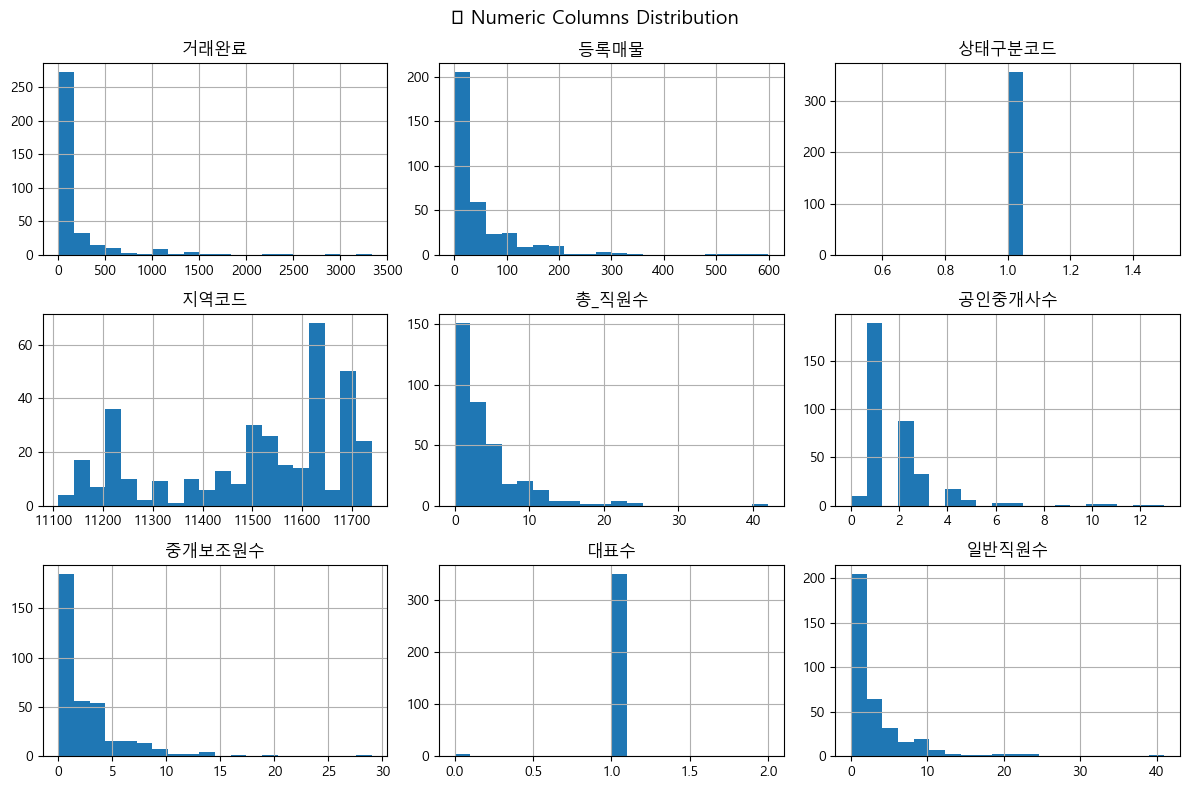


 describe(include='all') 결과


,등록번호,중개사명,대표자,전화번호,주소,거래완료,등록매물,개설시작일,개설종료일,등록일,상태구분코드,상태구분명,지역코드,지역명,도로명주소코드,최종수정일,총_직원수,공인중개사수,중개보조원수,대표수,일반직원수,직원목록_JSON,직원명단
count,356,356,356,356,356,356.000000,356.000000,356,356,356,356.0,356,356.000000,356,356,356,356.000000,356.000000,356.000000,356.000000,356.000000,356,351
unique,356,327,354,356,356,NaN,NaN,229,229,323,NaN,1,NaN,25,349,1,NaN,NaN,NaN,NaN,NaN,352,351
top,11170-2015-00203,베스트공인중개사사무소,박지연,02-794-3900,서울특별시 용산구 남영동 83-1 1층,NaN,NaN,2025-08-25,2026-08-24,2025-07-01,NaN,영업중,NaN,서울특별시 관악구,11680416674300000600000,2025-12-02,NaN,NaN,NaN,NaN,NaN,[],"김정숙, 김태진"
freq,1,3,2,1,1,NaN,NaN,6,6,4,NaN,356,NaN,68,3,356,NaN,NaN,NaN,NaN,NaN,5,1
mean,NaN,NaN,NaN,NaN,NaN,188.764045,54.087079,NaN,NaN,NaN,1.0,NaN,11499.367978,NaN,NaN,NaN,4.452247,1.901685,2.514045,0.988764,3.452247,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,414.022372,79.546502,NaN,NaN,NaN,0.0,NaN,177.725717,NaN,NaN,NaN,4.556434,1.730879,3.357955,0.129518,4.545293,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,1.0,NaN,11110.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,8.000000,10.000000,NaN,NaN,NaN,1.0,NaN,11380.000000,NaN,NaN,NaN,2.000000,1.000000,0.000000,1.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,40.000000,23.000000,NaN,NaN,NaN,1.0,NaN,11545.000000,NaN,NaN,NaN,3.000000,1.000000,1.000000,1.000000,2.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,157.750000,62.000000,NaN,NaN,NaN,1.0,NaN,11620.000000,NaN,NaN,NaN,5.000000,2.000000,3.000000,1.000000,4.000000,NaN,NaN


In [4]:
# 전체 히스토그램 (수치형 컬럼만)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(f"수치형 컬럼: {numeric_cols.tolist()}")

df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("📊 Numeric Columns Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# 요약통계
print("\n describe(include='all') 결과")
display(df.describe(include='all'))


In [5]:
print(df.columns.tolist())
df.info()

['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   등록번호       356 non-null    object 
 1   중개사명       356 non-null    object 
 2   대표자        356 non-null    object 
 3   전화번호       356 non-null    object 
 4   주소         356 non-null    object 
 5   거래완료       356 non-null    int64  
 6   등록매물       356 non-null    int64  
 7   개설시작일      356 non-null    object 
 8   개설종료일      356 non-null    object 
 9   등록일        356 non-null    object 
 10  상태구분코드     356 non-null    float64
 11  상태구분명      356 non-null    object 
 12  지역코드       356 non-null    float64
 13  지역명        356 non-null    object 
 14  도로명주소코드    356 non-null    object 
 15  최종수정일      

## 전체 거래 성사율(success_rate) 분석

In [6]:
# success_rate(거래 성사율) 파생 변수 생성

cols = ["거래완료", "등록매물"]

# -------------------------------------------------
# [0] "(숫자)건" 같은 값에서 숫자만 추출
#     예: "161건" -> "161", "10건" -> "10", 빈칸 / 이상값 -> NaN
# -------------------------------------------------
clean = (
    df[cols]
    .astype(str)                             # 전부 문자열로
    .apply(lambda s: s.str.extract(r"(\d+)", expand=False))  
    # ↑ 각 셀에서 연속된 숫자(\d+) 패턴만 뽑음. 없으면 NaN
)

# NaN 이 하나라도 있는 행 = 삭제 대상
invalid_mask = clean.isna().any(axis=1)

print(f"⚠ 삭제 대상 행 수: {invalid_mask.sum()}")

# 실제로 행 삭제
df = df[~invalid_mask].copy()
clean = clean[~invalid_mask]

# 숫자로 변환
df[cols] = clean.astype(int)

df.info()   # 여기서 거래완료/등록매물 dtype 이 int64 인지 확인

⚠ 삭제 대상 행 수: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   등록번호       356 non-null    object 
 1   중개사명       356 non-null    object 
 2   대표자        356 non-null    object 
 3   전화번호       356 non-null    object 
 4   주소         356 non-null    object 
 5   거래완료       356 non-null    int64  
 6   등록매물       356 non-null    int64  
 7   개설시작일      356 non-null    object 
 8   개설종료일      356 non-null    object 
 9   등록일        356 non-null    object 
 10  상태구분코드     356 non-null    float64
 11  상태구분명      356 non-null    object 
 12  지역코드       356 non-null    float64
 13  지역명        356 non-null    object 
 14  도로명주소코드    356 non-null    object 
 15  최종수정일      356 non-null    object 
 16  총_직원수      356 non-null    int64  
 17  공인중개사수     356 non-null    int64  
 18  중개보조원수     356 non-null    int64  
 19  대표수        356 non-null    int64  


In [7]:
clean_path = "C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv"  # 처음에 읽어온 경로와 동일하게

df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print(f"✅ 정제된 데이터 저장 완료: {clean_path}")

✅ 정제된 데이터 저장 완료: C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv



📈 success_rate 기본 통계 + 분위수
count    356.000000
mean       0.535024
std        0.330702
min        0.000000
10%        0.043040
25%        0.247172
50%        0.560425
75%        0.853880
90%        0.942494
95%        0.964989
max        0.992958
Name: success_rate, dtype: float64


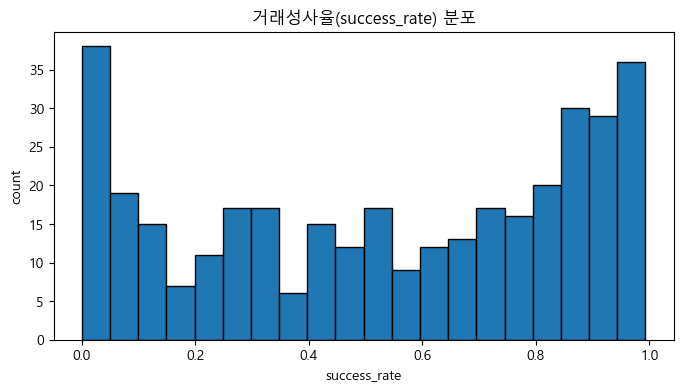

In [8]:
# 1) 저장해둔 클린 데이터 다시 로드 (이미 df 있으면 이 부분은 생략해도 됨)
clean_path = "C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv"
df = pd.read_csv(clean_path)

# 2) 혹시 모를 안전용: 총매물수 / success_rate 다시 한 번 계산
df["총매물수"] = df["거래완료"] + df["등록매물"]
df["success_rate"] = df["거래완료"] / (df["총매물수"] + 1e-6)

# 3) 기본 통계 + 분위수 보기
print("\n📈 success_rate 기본 통계 + 분위수")
print(
    df["success_rate"].describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

# 4) 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["success_rate"], bins=20, edgecolor="black")
plt.title("거래성사율(success_rate) 분포")
plt.xlabel("success_rate")
plt.ylabel("count")
plt.show()


## 총매물건수 대비 지역별 총매물건수 분포

In [9]:
# ------------------------------------------
# 1) 지역별 총매물수 합계
# ------------------------------------------
region_total = (
    df.groupby("지역명")["총매물수"]
      .sum()
      .sort_values(ascending=False)
)

# ------------------------------------------
# 2) 서울 전체 총매물수 구하기
# ------------------------------------------
seoul_total = region_total.sum()   # 모든 지역 합 → 서울 전체 매물수

print(f"📌 서울 전체 총매물수: {seoul_total:,} 건")

# ------------------------------------------
# 3) 지역별 비중(%) 계산
# ------------------------------------------
region_ratio = (region_total / seoul_total) * 100  # 비율 %

# ------------------------------------------
# 4) 결과 출력 (상위 20개 예시)
# ------------------------------------------
print("\n📍 서울 전체 대비 지역별 총매물수 비율 (%)")
display(region_ratio.round(2))

📌 서울 전체 총매물수: 86,455 건

📍 서울 전체 대비 지역별 총매물수 비율 (%)


지역명
서울특별시 관악구     32.71
서울특별시 강남구     12.77
서울특별시 금천구      8.35
서울특별시 강서구      8.22
서울특별시 중랑구      5.16
서울특별시 동작구      3.70
서울특별시 마포구      3.68
서울특별시 송파구      3.52
서울특별시 광진구      3.39
서울특별시 은평구      2.71
서울특별시 용산구      2.36
서울특별시 영등포구     2.23
서울특별시 양천구      2.06
서울특별시 서대문구     1.97
서울특별시 동대문구     1.59
서울특별시 구로구      1.33
서울특별시 강북구      1.16
서울특별시 노원구      0.85
서울특별시 서초구      0.70
서울특별시 강동구      0.59
서울특별시 성동구      0.53
서울특별시 중구       0.16
서울특별시 종로구      0.10
서울특별시 도봉구      0.08
서울특별시 성북구      0.07
Name: 총매물수, dtype: float64

In [10]:
region = (
    df.groupby("지역명")[["거래완료", "총매물수"]]
      .sum()
)

region["success_rate"] = region["거래완료"] / region["총매물수"]
region["size_share"] = region["총매물수"] / region["총매물수"].sum()  # 서울 대비 비율

# 너무 작은 지역(예: 전체의 500 미만)은 표시만 다르게 하거나, 분석에서 제외해도 됨
threshold_cnt = 500  # 기준 매물 수(원하는 값으로 바꿔)
small_mask = region["총매물수"] < threshold_cnt

print("🔍 거래완료 매물 500건 이하 지역 수:", small_mask.sum())
print("   (제외 대상 지역 목록)")
display(region[small_mask])

# ✅ 1) region에서 작은 표본 지역 제거
region_filtered = region[~small_mask].copy()

print("\n✅ 작은 표본 지역 제거 후 region (요약)")
display(region_filtered.sort_values("size_share", ascending=False))

# ✅ 2) 원본 df에서도 같은 지역들 제거하고 싶다면 (선택)
#    → 분석/모델링에서 아예 빼고 쓸 때 사용
valid_regions = region_filtered.index
df_filtered = df[df["지역명"].isin(valid_regions)].copy()

print("\n✅ df에서도 작은 표본 지역 제거 후 행 개수:", len(df_filtered))


🔍 거래완료 매물 500건 이하 지역 수: 5
   (제외 대상 지역 목록)


,거래완료,총매물수,success_rate,size_share
지역명,,,,
서울특별시 도봉구,6,70,0.085714,0.000810
서울특별시 성동구,392,461,0.850325,0.005332
서울특별시 성북구,42,58,0.724138,0.000671
서울특별시 종로구,42,86,0.488372,0.000995
서울특별시 중구,122,140,0.871429,0.001619



✅ 작은 표본 지역 제거 후 region (요약)


,거래완료,총매물수,success_rate,size_share
지역명,,,,
서울특별시 관악구,22740,28278,0.804159,0.327083
서울특별시 강남구,7033,11042,0.636932,0.127720
서울특별시 금천구,5776,7223,0.799668,0.083546
서울특별시 강서구,5723,7108,0.805149,0.082216
서울특별시 중랑구,4031,4461,0.903609,0.051599
서울특별시 동작구,2255,3195,0.705790,0.036956
서울특별시 마포구,2291,3183,0.719761,0.036817
서울특별시 송파구,2441,3045,0.801642,0.035221
서울특별시 광진구,2268,2928,0.774590,0.033867



✅ df에서도 작은 표본 지역 제거 후 행 개수: 340


In [11]:
# 0) 원본 백업
df_raw = df.copy()   # 원본 df는 df_raw로 보관

# 1) 지역별 집계: 거래완료 / 총매물수
region_total_raw = (
    df.groupby("지역명")[["거래완료", "총매물수"]]
      .sum()
)

# 2) 너무 작은 지역 찾기 (예: 총매물수 500건 미만)
threshold_cnt = 500
small_regions = region_total_raw.query("총매물수 < @threshold_cnt").index

print("🔍 너무 표본이 작은 지역 수:", len(small_regions))
print("   (제외 대상 지역명 목록)")
display(small_regions)

# 3) df에서 작은 지역 제거 → 필터링된 df 생성
df_filtered = df[~df["지역명"].isin(small_regions)].copy()
print("\n✅ 필터링 전 행 수:", len(df))
print("✅ 필터링 후 행 수:", len(df_filtered))

# 4) 앞으로는 df_filtered를 df 이름으로 사용
df = df_filtered

🔍 너무 표본이 작은 지역 수: 5
   (제외 대상 지역명 목록)


Index(['서울특별시 도봉구', '서울특별시 성동구', '서울특별시 성북구', '서울특별시 종로구', '서울특별시 중구'], dtype='object', name='지역명')


✅ 필터링 전 행 수: 356
✅ 필터링 후 행 수: 340


🔍 기준(500건) 미만 지역 수: 0개
   (제외 목록: [])
✅ 필터링 전: 340행 -> 후: 340행


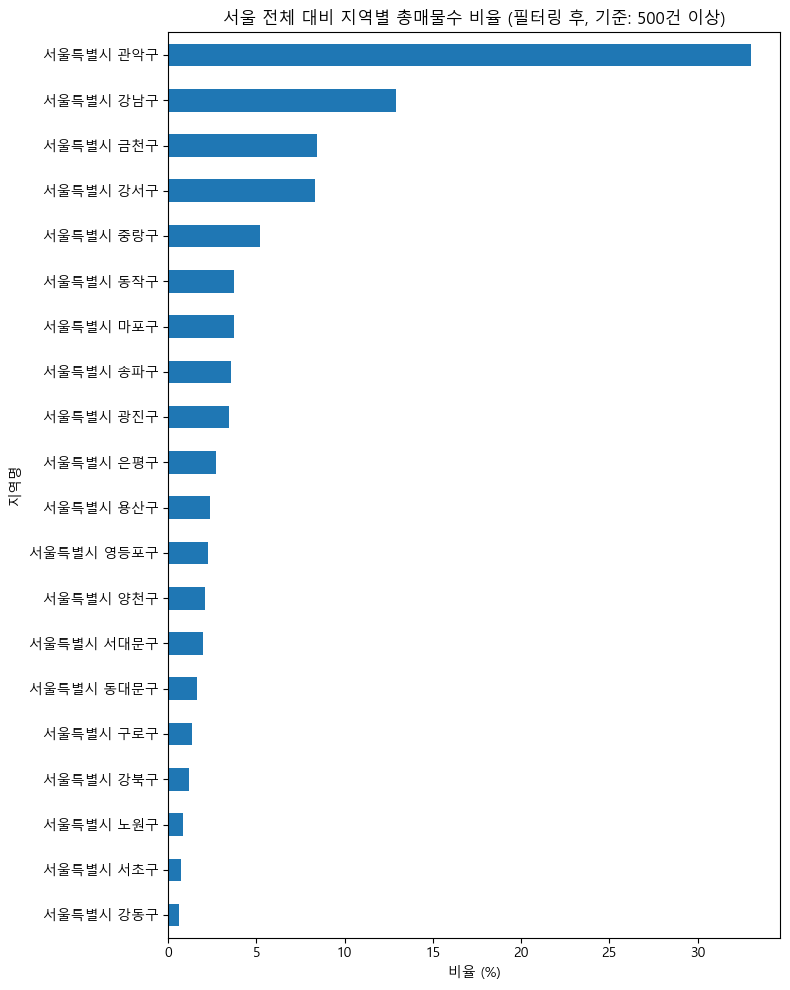

In [12]:
# --------------------------------------------------------------------------------
# 1. 설정: 제거할 기준 설정 (총매물수 500건 미만)
# --------------------------------------------------------------------------------
threshold_cnt = 500

# --------------------------------------------------------------------------------
# 2. 집계 및 필터링 대상 식별
# --------------------------------------------------------------------------------
# 원본 보호를 위해 복사본 생성 (선택 사항)
if 'df_raw' not in locals():
    df_raw = df.copy()

# 지역별 총매물수 집계
region_counts = df.groupby("지역명")["총매물수"].sum()

# 기준 미만인 지역명 찾기
small_regions = region_counts[region_counts < threshold_cnt].index

# --------------------------------------------------------------------------------
# 3. 데이터프레임(df) 업데이트: 작은 지역 제거
# --------------------------------------------------------------------------------
df_filtered = df[~df["지역명"].isin(small_regions)].copy()

print(f"🔍 기준({threshold_cnt}건) 미만 지역 수: {len(small_regions)}개")
print(f"   (제외 목록: {list(small_regions)})")
print(f"✅ 필터링 전: {len(df)}행 -> 후: {len(df_filtered)}행")

# ★ 핵심: 이후 분석을 위해 df 변수 자체를 덮어쓰기
df = df_filtered

# --------------------------------------------------------------------------------
# 4. 검증용 그래프 그리기 (변경된 df 기준 재계산)
# --------------------------------------------------------------------------------
# 필터링된 df로 다시 집계
new_region_total = df.groupby("지역명")["총매물수"].sum()

# 비율(%) 재계산
region_ratio = (new_region_total / new_region_total.sum()) * 100

# 시각화
plt.figure(figsize=(8, 10))
region_ratio.sort_values().plot(kind="barh")
plt.title(f"서울 전체 대비 지역별 총매물수 비율 (필터링 후, 기준: {threshold_cnt}건 이상)")
plt.xlabel("비율 (%)")
plt.tight_layout()
plt.show()


📈 지역별 거래성사율(비율) 기본 통계 + 분위수 (% 단위)
 count: 20
  mean:  76.27%
   std:  13.06%
   min:  35.88%
   10%:  63.59%
   25%:  69.79%
   50%:  80.07%
   75%:  81.86%
   90%:  90.39%
   95%:  90.84%
   max:  94.42%

📍 지역별 거래성사율 (% 단위)


,거래완료,총매물수,비율(%)
지역명,,,
서울특별시 노원구,694,735,94.42
서울특별시 용산구,1852,2043,90.65
서울특별시 중랑구,4031,4461,90.36
서울특별시 은평구,2076,2343,88.60
서울특별시 서대문구,1397,1705,81.94
서울특별시 양천구,1455,1778,81.83
서울특별시 강북구,818,1000,81.80
서울특별시 강서구,5723,7108,80.51
서울특별시 관악구,22740,28278,80.42


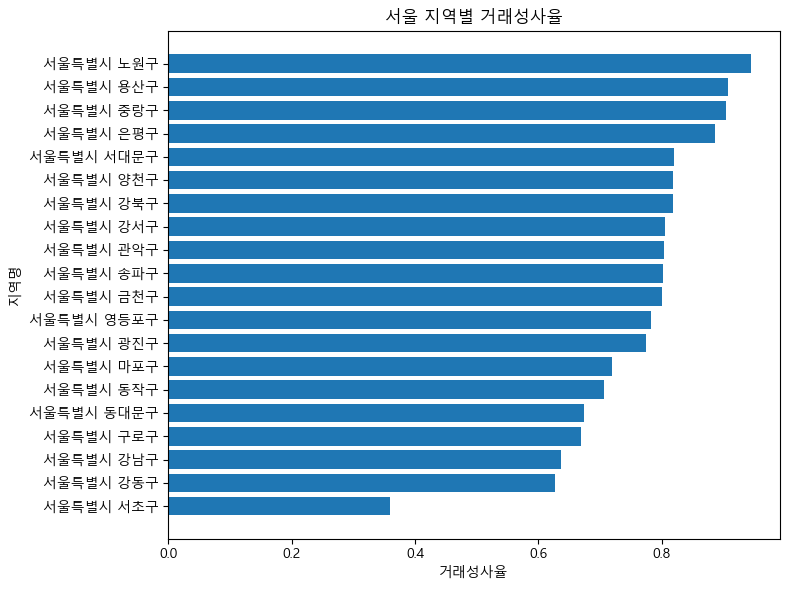

In [36]:
# ------------------------------------------
# [1] 지역별 거래완료 / 총매물수 합계
# ------------------------------------------
region_total = (
    df.groupby("지역명")[["거래완료", "총매물수"]]
      .sum()
)

# 비율 컬럼 추가: 지역 전체 거래성사율
region_total["비율"] = region_total["거래완료"] / region_total["총매물수"]

# 🔹 (A) 요약 통계 + 분위수 (% 단위)  ← 이건 그대로 두고
stats = region_total["비율"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
)

stats_pct = stats.copy()
mask = stats_pct.index != "count"
stats_pct[mask] = stats_pct[mask] * 100

print("\n📈 지역별 거래성사율(비율) 기본 통계 + 분위수 (% 단위)")
for idx, val in stats_pct.items():
    if idx == "count":
        print(f"{idx:>6}: {val:.0f}")
    else:
        print(f"{idx:>6}: {val:6.2f}%")

# 🔹 (B) 각 지역별 거래성사율을 %로 보기
region_total["비율(%)"] = (region_total["비율"] * 100).round(2)

print("\n📍 지역별 거래성사율 (% 단위)")
display(region_total[["거래완료", "총매물수", "비율(%)"]]
        .sort_values("비율(%)", ascending=False))
#        ↑ 정렬 방향 바꾸고 싶으면 True/False 조절

# ------------------------------------------
# [2] 비율 높은/낮은 순으로 정렬 (그래프용)
# ------------------------------------------
region_total = region_total.sort_values("비율", ascending=True)

# ------------------------------------------
# [3] 가로 막대그래프
# ------------------------------------------
plt.figure(figsize=(8, 6))
plt.barh(region_total.index, region_total["비율"])
plt.title("서울 지역별 거래성사율")
plt.xlabel("거래성사율")
plt.ylabel("지역명")
plt.tight_layout()
plt.show()

## 지역별 총매물건수·지역별 거래성사율 지역보정

### 대시보드/해석용: 단순 필터 + 2축
- > x축 : 총매물수 비율(=시장규모)
- > y축 : 거래성사율(=퍼포먼스)

In [25]:
region = (
    df.groupby("지역명")[["거래완료", "총매물수"]]
      .sum()
)

region["success_rate"] = region["거래완료"] / region["총매물수"]
region["size_share"] = region["총매물수"] / region["총매물수"].sum()  # 서울 대비 비율

# 너무 작은 지역(예: 전체의 500 미만)은 표시만 다르게 하거나, 분석에서 제외해도 됨
threshold_cnt = 500  # 기준 매물 수(원하는 값으로 바꿔)
small_mask = region["총매물수"] < threshold_cnt

print("🔍 너무 표본이 작은 지역 수:", small_mask.sum())
display(region.sort_values("size_share", ascending=False))


🔍 너무 표본이 작은 지역 수: 0


,거래완료,총매물수,success_rate,size_share
지역명,,,,
서울특별시 관악구,22740,28278,0.804159,0.330196
서울특별시 강남구,7033,11042,0.636932,0.128935
서울특별시 금천구,5776,7223,0.799668,0.084341
서울특별시 강서구,5723,7108,0.805149,0.082999
서울특별시 중랑구,4031,4461,0.903609,0.052090
서울특별시 동작구,2255,3195,0.705790,0.037307
서울특별시 마포구,2291,3183,0.719761,0.037167
서울특별시 송파구,2441,3045,0.801642,0.035556
서울특별시 광진구,2268,2928,0.774590,0.034190


### 모델지표용모델/지표용: 볼륨 기반 shrinkage(지역보정 성사율)

In [26]:
region = (
    df.groupby("지역명")[["거래완료", "총매물수"]]
      .sum()
)

region["success_rate"] = region["거래완료"] / region["총매물수"]
region["size_share"] = region["총매물수"] / region["총매물수"].sum()


In [27]:
# 방법1: 지역 단위 평균
global_mean = region["success_rate"].mean()

# 방법2: 매물 수 기준 가중 평균 (조금 더 직관적일 수 있음)
global_mean_weighted = (region["success_rate"] * region["총매물수"]).sum() / region["총매물수"].sum()

print("서울 전체 평균 성사율 (지역평균 기준):", global_mean)
print("서울 전체 평균 성사율 (매물 가중 기준):", global_mean_weighted)


서울 전체 평균 성사율 (지역평균 기준): 0.762741798924042
서울 전체 평균 성사율 (매물 가중 기준): 0.777627276973377


In [28]:
# size_share: 0 ~ 1 사이 값 (예: 0.3271 = 32.71%)
# 0.05 (= 5%) 이상이면 weight=1, 그 이하면 비례해서 줄이기
region["weight"] = (region["size_share"] / 0.05).clip(0, 1)


In [29]:
base = global_mean_weighted  # 또는 global_mean

region["success_rate_adj"] = base + region["weight"] * (region["success_rate"] - base)

In [30]:
# 1) 비율 높은 순으로 정렬
region_seoul = region_seoul.sort_values("비율", ascending=True)  # barh 위에서 아래로 예쁘게

# 2) 가로 막대그래프
plt.figure(figsize=(8, 6))
plt.barh(region_seoul["ldCodeNm"], region_seoul["비율(%)"], edgecolor="black")

plt.title("서울시 지역별 매물 분포율(%)")
plt.xlabel("비율(%)")
plt.ylabel("지역")

# 값이 큰 애가 위로 오게 하려면 (정렬을 ascending=True로 했으니까 뒤집기)
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'region_seoul' is not defined

In [ ]:
# 1) 지역별 총매물수 집계 (원본 df 사용)
# ldCodeNm 별로 '총매물수'를 합산합니다.
region_total = df.groupby("ldCodeNm")['총매물수'].sum().reset_index()

# 2) 전체 대비 비율(%) 계산
total_listings = region_total['총매물수'].sum()
region_total['비율(%)'] = (region_total['총매물수'] / total_listings) * 100

# 3) 필터링: "서울" 포함 AND 총매물수 >= 500
# 조건 설정
cond_seoul = region_total["ldCodeNm"].str.contains("서울")
cond_over_500 = region_total["총매물수"] >= 500

# 필터 적용
region_seoul_filtered = region_total[cond_seoul & cond_over_500].copy()

# 4) 비율 높은 순으로 정렬 (그래프 시각화용)
region_seoul_filtered = region_seoul_filtered.sort_values("비율(%)", ascending=True)

# ----------------- 시각화 -----------------
plt.figure(figsize=(10, 8))  # 그래프 크기 조절

# 가로 막대그래프 그리기
bars = plt.barh(region_seoul_filtered["ldCodeNm"], region_seoul_filtered["비율(%)"], 
                edgecolor="black", color='skyblue')

plt.title("서울시 지역별 매물 분포율(%) [매물 500건 이상]", fontsize=14)
plt.xlabel("비율(%)", fontsize=12)
plt.ylabel("지역", fontsize=12)


# 막대 옆에 수치(건수, %) 표시 (선택사항)
for bar in bars:
    width = bar.get_width()
    # 해당 막대의 인덱스를 찾아 총매물수 가져오기 (약간 복잡할 수 있어 비율만 표시하거나 생략 가능)
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 통계 출력
print("=== 서울시 지역별 매물 현황 (500건 이상) ===")
display(region_seoul_filtered[["ldCodeNm", "총매물수", "비율(%)"]].sort_values("총매물수", ascending=False))

In [ ]:
# 1) 살아남은 지역 리스트 추출 (총매물수 500건 이상인 서울 지역)
# region_seoul_filtered는 이전 단계에서 이미 만들어진 데이터프레임입니다.
target_regions = region_seoul_filtered["ldCodeNm"].unique()

# 2) 원본 df에서 해당 지역들만 필터링
df_filtered = df[df["ldCodeNm"].isin(target_regions)].copy()

# 3) 지역별 거래완료 & 총매물수 합계 집계
# 단순 평균(mean)이 아니라, 지역 전체의 (총 거래완료 수 / 총 매물 수)로 계산해야 정확합니다.
region_stats = df_filtered.groupby("ldCodeNm")[["거래완료", "총매물수"]].sum().reset_index()

# 4) 거래 성사율 계산
# 0으로 나누는 것을 방지하기 위해 분모에 작은 값(1e-9)을 더해주거나 처리할 수 있으나, 500건 이상이므로 그대로 진행합니다.
region_stats["거래성사율(%)"] = (region_stats["거래완료"] / region_stats["총매물수"]) * 100

# 5) 성사율 높은 순으로 정렬
region_stats = region_stats.sort_values("거래성사율(%)", ascending=True)

# ----------------- 시각화 -----------------
plt.figure(figsize=(10, 8))

# 가로 막대 그래프
# 색상은 가시성을 위해 다른 색(예: 'lightgreen') 사용
bars = plt.barh(region_stats["ldCodeNm"], region_stats["거래성사율(%)"], 
                edgecolor="black", color='lightgreen')

plt.title("서울시 주요 지역(매물 500건↑) 거래 성사율(%)", fontsize=14)
plt.xlabel("거래 성사율 (%)", fontsize=12)
plt.ylabel("지역", fontsize=12)

# 막대 옆에 수치 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 결과 텍스트 출력
print("=== 서울시 주요 지역(매물 500건 이상) 거래 성사율 순위 ===")
display(region_stats[["ldCodeNm", "거래완료", "총매물수", "거래성사율(%)"]].sort_values("거래성사율(%)", ascending=False))

In [ ]:
# 1) 숫자형 정리
df["거래완료"] = pd.to_numeric(df["거래완료"], errors="coerce").fillna(0)
df["총매물수"] = pd.to_numeric(df["총매물수"], errors="coerce").fillna(0)

# 2) 지역별 집계 (거래완료 합, 총매물수 합)
region_agg = (
    df.groupby("ldCodeNm")[["거래완료", "총매물수"]]
      .sum()
      .reset_index()
)

# 3) 지역별 성사율 계산
region_agg["region_success_rate"] = (
    region_agg["거래완료"] / (region_agg["총매물수"] + 1e-6)
)

# 4) 서울만 필터링
region_seoul = region_agg[region_agg["ldCodeNm"].str.contains("서울")].copy()

# 5) 그래프 보기 좋게 오름차순 정렬
region_seoul = region_seoul.sort_values("region_success_rate", ascending=True)

print(region_seoul)

# 6) 가로막대그래프(barh)
plt.figure(figsize=(9, 8))
plt.barh(
    region_seoul["ldCodeNm"],
    region_seoul["region_success_rate"],
    color="skyblue",
    edgecolor="black"
)

plt.title("서울시 지역별 거래 성사율")
plt.xlabel("거래 성사율 (region_success_rate)")
plt.ylabel("지역")

# 성사율 값 표시 (선택)
for index, value in enumerate(region_seoul["region_success_rate"]):
    plt.text(value + 0.001, index, f"{value:.3f}", va='center')

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 보증보험 분석

In [ ]:
# 보증보험 유효 여부 확인

# 날짜 변환
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

# 거래성사율 생성 (없으면)
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

# 보증보험 유효 여부
today = pd.Timestamp.today()
df["보증보험유효"] = (df["estbsEndDe"] >= today).astype(int)

print(f"유효: {df['보증보험유효'].sum()}개")
print(f"만료: {(df['보증보험유효'] == 0).sum()}개")

# 만료된 중개사 전체 정보
expired = df[df['보증보험유효'] == 0]

if len(expired) > 0:
    print(f"\n보증보험 만료 중개사 ({len(expired)}개):\n")
    
    for idx, row in expired.iterrows():
        print(f"{'='*60}")
        print(f"중개사: {row['brkrNm']} ({row['bsnmCmpnm']})")
        print(f"지역: {row['ldCodeNm']}")
        print(f"보험만료: {row['estbsEndDe'].strftime('%Y-%m-%d')}")
        print(f"거래완료: {row['거래완료']}건 / 총매물: {row['총매물수']}건")
        print(f"거래성사율: {row['거래성사율']:.1%}")
        print()


## 개업일(registDe) 분석

In [ ]:
# 날짜로 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

print("\n📈 years_active 기본 통계")
print(df["years_active"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["years_active"], bins=20, color='orange', edgecolor='black')
plt.title("중개사 개업 연차 분포")
plt.xlabel("years_active")
plt.ylabel("count")
plt.show()


In [ ]:
# 연차 vs 거래성사율 상관관계 분석

# 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

# 상관계수 계산
correlation = df[["years_active", "거래성사율"]].corr().iloc[0, 1]
print(f"상관계수: {correlation:.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot with regression line
axes[0].scatter(df["years_active"], df["거래성사율"], alpha=0.5, s=30)
z = np.polyfit(df["years_active"], df["거래성사율"], 1)
p = np.poly1d(z)
axes[0].plot(df["years_active"], p(df["years_active"]), "r--", linewidth=2, label=f'회귀선 (r={correlation:.3f})')
axes[0].set_xlabel('활동 연차', fontsize=12)
axes[0].set_ylabel('거래성사율', fontsize=12)
axes[0].set_title('연차 vs 거래성사율', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Boxplot (연차 구간별)
df['연차구간'] = pd.cut(df['years_active'], bins=[0, 5, 10, 15, 20, 100], 
                        labels=['0-5년', '6-10년', '11-15년', '16-20년', '20년+'])
df.boxplot(column='거래성사율', by='연차구간', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('연차 구간', fontsize=12)
axes[1].set_ylabel('거래성사율', fontsize=12)
axes[1].set_title('연차 구간별 거래성사율 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()


## 컬럼 간 상관관계 분석

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["거래완료","등록매물","총매물수","success_rate","years_active"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계 분석")
plt.show()


## 지역별 분석

In [ ]:
# 1. 지역별 기본 통계

if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

region_stats = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래완료': ['mean', 'median', 'sum'],
    '총매물수': ['mean', 'median'],
    '거래성사율': ['mean', 'median']
}).round(2)

region_stats.columns = ['중개사수', '평균거래', '중앙거래', '총거래', '평균매물', '중앙매물', '평균성사율', '중앙성사율']
region_stats = region_stats.sort_values('평균성사율', ascending=False)

print("="*70)
print("지역별 통계")
print("="*70)
print(region_stats)

In [ ]:
# 2. 시각화 - 지역별 중개사 수
plt.figure(figsize=(12, 6))
region_counts = df['ldCodeNm'].value_counts()
region_counts.plot(kind='bar', color='steelblue')
plt.title('지역별 중개사 수', fontsize= 14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('중개사 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 3. 시각화 - 지역별 평균 거래성사율
plt.figure(figsize=(12, 6))
region_success = df.groupby('ldCodeNm')['거래성사율'].mean().sort_values(ascending=False)
region_success.plot(kind='bar', color='green', alpha=0.7)
plt.title('지역별 평균 거래성사율', fontsize=14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('평균 거래성사율')
plt.axhline(df['거래성사율'].mean(), color='red', linestyle='--', label=f'전체 평균: {df["거래성사율"].mean():.1%}')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4. 지역별 규모 vs 성과
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 중개사 수 vs 평균 성과
region_summary = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래성사율': 'mean',
    '총매물수': 'mean'
})
region_summary.columns = ['중개사수', '평균성사율', '평균매물수']

axes[0].scatter(region_summary['중개사수'], region_summary['평균성사율'], 
                s=region_summary['평균매물수']/10, alpha=0.6, c=region_summary['평균성사율'], 
                cmap='RdYlGn')
axes[0].set_xlabel('지역 내 중개사 수')
axes[0].set_ylabel('평균 거래성사율')
axes[0].set_title('지역별 중개사 수 vs 평균 성과')

# 평균 매물수 vs 평균 성과
axes[1].scatter(region_summary['평균매물수'], region_summary['평균성사율'],
                s=region_summary['중개사수']*10, alpha=0.6, c=region_summary['평균성사율'],
                cmap='RdYlGn')
axes[1].set_xlabel('평균 총매물수')
axes[1].set_ylabel('평균 거래성사율')
axes[1].set_title('지역별 평균 규모 vs 평균 성과')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [ ]:
df["bsnmCmpnm"].nunique()

In [ ]:
office_counts = df["bsnmCmpnm"].value_counts()

print("중복된 상호명 개수:", (office_counts > 1).sum())
print("\n상위 중복 상호명:")
print(office_counts[office_counts > 1].head(10))

# 중복된 상호명의 실제 데이터 확인
duplicated_offices = office_counts[office_counts > 1].index[:3]
for office in duplicated_offices:
    print(f"\n{'='*60}")
    print(f"상호명: {office}")
    print(df[df['bsnmCmpnm'] == office][['brkrNm', 'ldCodeNm', '등록번호', '거래완료', '총매물수']])


---

# 파생 피처 생성

In [ ]:
# 0. 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

In [ ]:
# 1. 거래 효율성 피처
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)
df['재고율'] = df['등록매물'] / (df['총매물수'] + 1)
df['거래재고비'] = df['거래완료'] / (df['등록매물'] + 1)

# 2. 규모 관련 피처
df['총매물수_로그'] = np.log1p(df['총매물수'])
df['안정구간여부'] = (df['총매물수'] >= 100).astype(int)
df['규모등급'] = pd.cut(df['총매물수'], 
                        bins=[0, 50, 100, 500, 1000, float('inf')],
                        labels=['초소형', '소형', '중형', '대형', '초대형'])


In [ ]:
# 3. 시간 관련 피처
df['영업일수'] = (df['estbsEndDe'] - df['estbsBeginDe']).dt.days
df['등록일수'] = (pd.Timestamp.now() - df['registDe']).dt.days
df['영업년수'] = df['영업일수'] / 365
df['등록년수'] = df['등록일수'] / 365

In [ ]:
# 4. 활동성 피처

df['일평균거래'] = df['거래완료'] / (df['영업일수'] + 1)
df['일평균매물'] = df['총매물수'] / (df['영업일수'] + 1)
df['연평균거래'] = df['거래완료'] / (df['영업년수'] + 1)

In [ ]:
# 5. 지역 기반 피처
df['지역평균성사율'] = df.groupby('ldCodeNm')['거래성사율'].transform('mean')
df['지역대비성과'] = df['거래성사율'] - df['지역평균성사율']
df['지역평균매물수'] = df.groupby('ldCodeNm')['총매물수'].transform('mean')
df['지역내순위'] = df.groupby('ldCodeNm')['거래성사율'].rank(ascending=False, method='dense')

In [ ]:
# 6. 연차 관련 피처
if 'years_active' not in df.columns:
    df['years_active'] = pd.Timestamp.today().year - df['registDe'].dt.year
    
df['경험등급'] = pd.cut(df['years_active'],
                        bins=[0, 5, 10, 15, 20, 100],
                        labels=['신규', '초급', '중급', '고급', '전문가'])

In [ ]:
# 7. 성과 플래그
df['고성과플래그'] = ((df['거래성사율'] >= 0.95) & (df['총매물수'] >= 100)).astype(int)
df['저성과플래그'] = ((df['거래성사율'] < 0.5) & (df['총매물수'] >= 10)).astype(int)

In [ ]:
# 8. 상호작용 피처
df['규모X지역평균'] = df['총매물수_로그'] * df['지역평균성사율']
df['연차X규모'] = df['years_active'] * df['총매물수_로그']

In [ ]:
print(f"\n최종 데이터 shape: {df.shape}")
print(f"원본 컬럼: 13개")
print(f"생성된 피처: {df.shape[1] - 13}개")

In [ ]:
# ============================================================================
# 백분위 기반 등급 분류
# ============================================================================

# 백분위 기반 등급 (각 등급이 비슷한 비율로 분포)
df['trust_grade'] = pd.qcut(df['trust_score'], 
                             q=5, 
                             labels=['D', 'C', 'B', 'A', 'S'],
                             duplicates='drop')

print("="*70)
print("백분위 기반 등급 분포")
print("="*70)
grade_dist = df['trust_grade'].value_counts().sort_index()
for grade, count in grade_dist.items():
    pct = count / len(df) * 100
    print(f"  {grade}등급: {count:3d}개 ({pct:5.1f}%)")

# 등급별 점수 범위
print("\n등급별 점수 범위:")
grade_ranges = df.groupby('trust_grade')['trust_score'].agg(['min', 'max', 'mean'])
grade_ranges.columns = ['최소', '최대', '평균']
print(grade_ranges.round(1))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 분포 (파이 차트)
grade_counts = df['trust_grade'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffff00', '#2ca02c', '#1f77b4']  # D=빨강, C=주황, B=노랑, A=초록, S=파랑
axes[0].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('신뢰도 등급 분포', fontsize=13, fontweight='bold')

# 등급별 점수 박스플롯
df.boxplot(column='trust_score', by='trust_grade', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('등급', fontsize=12)
axes[1].set_ylabel('신뢰도 점수', fontsize=12)
axes[1].set_title('등급별 점수 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# 등급별 특성 비교
print("\n" + "="*70)
print("등급별 평균 특성")
print("="*70)
grade_features = df.groupby('trust_grade').agg({
    'trust_score': 'mean',
    '거래성사율': 'mean',
    '총매물수': 'mean',
    '재고율': 'mean',
    '일평균거래': 'mean',
    '영업년수': 'mean'
}).round(2)
grade_features.columns = ['평균점수', '거래성사율', '총매물수', '재고율', '일평균거래', '영업년수']
print(grade_features)

# 각 등급별 대표 중개사
print("\n" + "="*70)
print("등급별 대표 중개사 (각 등급 상위 3개)")
print("="*70)
for grade in ['S', 'A', 'B', 'C', 'D']:
    grade_df = df[df['trust_grade'] == grade].nlargest(3, 'trust_score')
    if len(grade_df) > 0:
        print(f"\n{grade}등급:")
        for idx, row in grade_df.iterrows():
            print(f"  - {row['brkrNm']} ({row['ldCodeNm']}): {row['trust_score']:.1f}점")


# 파생 피쳐 끝

## 학습에 쓸 데이터 준비

In [ ]:
# 타겟 변수
# 회귀: trust_score (0~100점 예측)
# 분류: trust_grade (S/A/B/C/D 예측)

# 사용할 피처 선택
feature_cols = [
    # 수치형 피처
    '총매물수_로그',
    '일평균거래',
    '연평균거래',
    '지역평균성사율',
    '지역대비성과',
    '지역내순위',
    '영업년수',
    '등록년수',
    '규모X지역평균',
    '연차X규모',
    '안정구간여부',
    
    # 카테고리 피처
    'ldCodeNm',
    '규모등급',
    '경험등급'
]

# 카테고리 vs 수치형 분리
categorical_features = ['ldCodeNm', '규모등급', '경험등급']
numerical_features = [col for col in feature_cols if col not in categorical_features]

print(f"수치형 피처: {len(numerical_features)}개")
print(numerical_features)
print(f"\n카테고리 피처: {len(categorical_features)}개")
print(categorical_features)


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# 회귀 문제로 진행 (점수 예측)
X = df[feature_cols]
y = df['trust_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 점수 범위: {y_train.min():.1f} ~ {y_train.max():.1f}")
print(f"Test 점수 범위: {y_test.min():.1f} ~ {y_test.max():.1f}")


## 전처리 파이프라인

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

print("✓ 전처리 파이프라인 생성 완료")


## 모델 학습

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0)
}

results = {}

for name, model in models.items():
    # 파이프라인 생성
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # 학습
    pipeline.fit(X_train, y_train)
    
    # 예측
    y_pred = pipeline.predict(X_test)
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mae,
        'R2': r2,
        'model': pipeline
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: {np.sqrt(mse):.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²: {r2:.3f}")

# 최고 성능 모델
best_model_name = max(results, key=lambda x: results[x]['R2'])
print(f"\n✓ 최고 성능 모델: {best_model_name} (R² = {results[best_model_name]['R2']:.3f})")


## 예측 결과 시각화

In [ ]:
best_model = results[best_model_name]['model']
y_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실제 vs 예측
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('실제 점수', fontsize=12)
axes[0].set_ylabel('예측 점수', fontsize=12)
axes[0].set_title(f'{best_model_name}: 실제 vs 예측', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# 오차 분포
errors = y_test - y_pred
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('오차 (실제 - 예측)', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)
axes[1].set_title('예측 오차 분포', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Test 데이터로 모델 성능 확인

In [ ]:
# 1. Test 데이터 예측
y_pred_test = best_model.predict(X_test)

# 2. 성능 지표 계산
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("="*70)
print(f"{best_model_name} - Test 데이터 성능")
print("="*70)
print(f"RMSE (평균 오차):     {rmse:.2f}점")
print(f"MAE (절대 오차):      {mae:.2f}점")
print(f"R² (결정계수):        {r2:.3f}")
print(f"\n해석:")
print(f"  - 평균적으로 실제 점수와 ±{mae:.1f}점 차이")
print(f"  - 전체 분산의 {r2*100:.1f}%를 설명")

# 3. Test 데이터 결과 상세 확인
test_results = pd.DataFrame({
    '실제점수': y_test.values,
    '예측점수': y_pred_test,
    '오차': y_test.values - y_pred_test,
    '절대오차': np.abs(y_test.values - y_pred_test)
})

# 원본 데이터 정보 추가
test_results['중개사명'] = df.loc[y_test.index, 'brkrNm'].values
test_results['지역'] = df.loc[y_test.index, 'ldCodeNm'].values
test_results['실제등급'] = df.loc[y_test.index, 'trust_grade'].values

# 예측 점수로 등급 부여
test_results['예측등급'] = pd.cut(test_results['예측점수'],
                                bins=df.groupby('trust_grade')['trust_score'].min().sort_values().values.tolist() + [100],
                                labels=['D', 'C', 'B', 'A', 'S'],
                                include_lowest=True)

print("\n" + "="*70)
print("Test 데이터 샘플 (랜덤 10개)")
print("="*70)
print(test_results.sample(10).to_string(index=False))

# 4. 오차가 큰 케이스 분석
print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과대평가)")
print("="*70)
worst_overpredict = test_results.nlargest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_overpredict.to_string(index=False))

print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과소평가)")
print("="*70)
worst_underpredict = test_results.nsmallest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_underpredict.to_string(index=False))

# 5. 등급 일치율
grade_match = (test_results['실제등급'] == test_results['예측등급']).sum()
grade_accuracy = grade_match / len(test_results) * 100

print("\n" + "="*70)
print("등급 예측 정확도")
print("="*70)
print(f"등급 일치: {grade_match}/{len(test_results)} ({grade_accuracy:.1f}%)")

# 등급별 혼동 행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_results['실제등급'], test_results['예측등급'], 
                      labels=['D', 'C', 'B', 'A', 'S'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['D', 'C', 'B', 'A', 'S'],
            yticklabels=['D', 'C', 'B', 'A', 'S'])
plt.xlabel('예측 등급', fontsize=12)
plt.ylabel('실제 등급', fontsize=12)
plt.title('등급 예측 혼동 행렬', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. 오차 통계
print("\n" + "="*70)
print("오차 통계")
print("="*70)
print(test_results['오차'].describe())


## SHAP으로 피처 중요도 분석

In [ ]:
# SHAP 설치 (필요시)
!pip install shap

import shap

# 1. SHAP Explainer 생성
# 전처리된 데이터 준비
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# 피처 이름 가져오기
feature_names = (numerical_features + 
                 list(best_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

print(f"전처리 후 피처 수: {len(feature_names)}개")

# Explainer 생성 (Gradient Boosting용)
explainer = shap.TreeExplainer(best_model.named_steps['regressor'])
shap_values = explainer.shap_values(X_test_transformed)

print("✓ SHAP 값 계산 완료")


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title('SHAP 피처 중요도 (전체)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
